# COSC 32000 — Assignment 1: K-Means Clustering
**Dataset:** Mall Customer Segmentation Data (Kaggle)  
**Link:** https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python

---
## PART 1: Data Loading & Exploration

### Task 1.1 — Load and Describe the Dataset

In [ ]:
import sys
!{sys.executable} -m pip install pandas numpy matplotlib seaborn scikit-learn

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score

# Seed for reproducibility
np.random.seed(42)

# ---------------------------------------------------------------
# Load dataset
# Download Mall_Customers.csv from the Kaggle link above and
# place it in the same folder as this notebook.
# ---------------------------------------------------------------
df = pd.read_csv('Mall_Customers.csv')

print('=== First 5 rows ===')
display(df.head())

print('\n=== Shape ===')
print(df.shape)

print('\n=== Data Types ===')
print(df.dtypes)

print('\n=== Missing Values ===')
print(df.isnull().sum())

=== First 5 rows ===


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40



=== Shape ===
(200, 5)

=== Data Types ===
CustomerID                int64
Gender                      str
Age                       int64
Annual Income (k$)        int64
Spending Score (1-100)    int64
dtype: object

=== Missing Values ===
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


### Task 1.2 — Exploratory Data Analysis (EDA)

In [33]:
print('=== Summary Statistics ===')
display(df.describe())

=== Summary Statistics ===


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


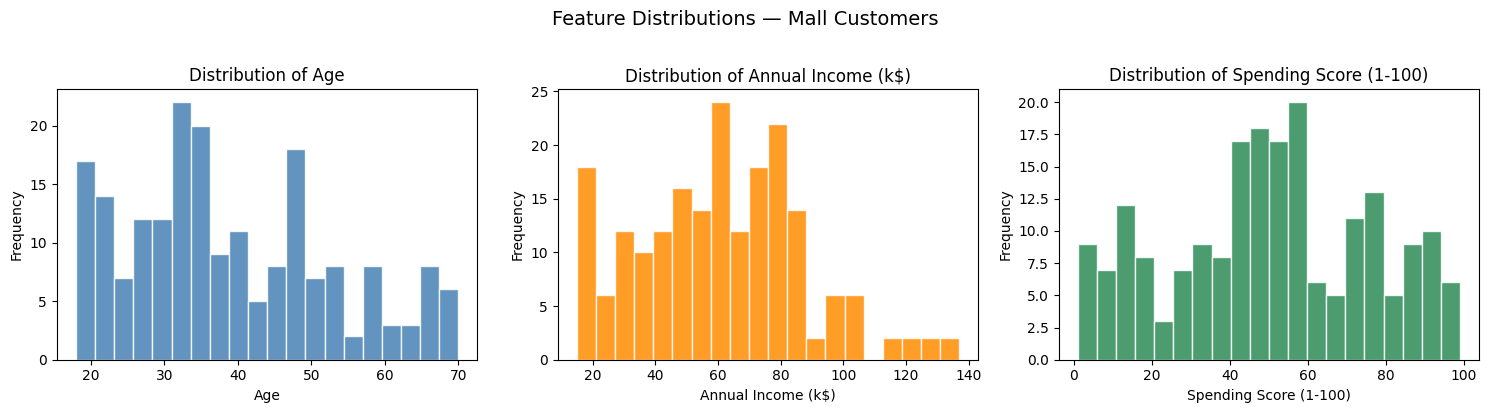

In [34]:
# --- Visualization 1: Distribution plots (histograms) ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
cols = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
colors = ['steelblue', 'darkorange', 'seagreen']
for ax, col, color in zip(axes, cols, colors):
    ax.hist(df[col], bins=20, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(f'Distribution of {col}', fontsize=12)
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
plt.suptitle('Feature Distributions — Mall Customers', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('eda_distributions.png', bbox_inches='tight', dpi=150)
plt.show()

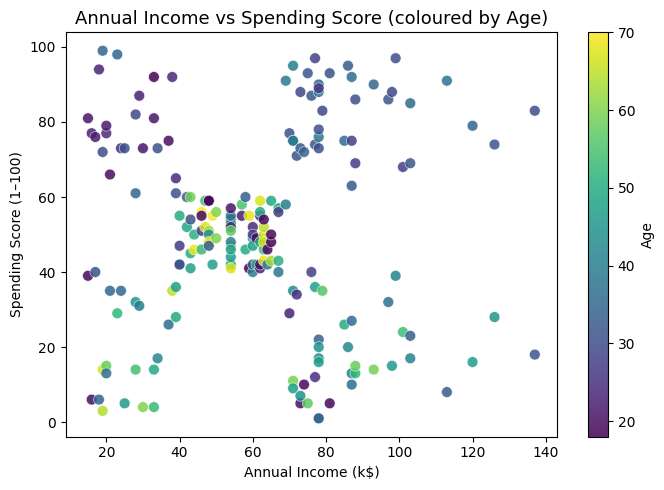

In [51]:
# --- Visualization 2: Scatter plot — Annual Income vs Spending Score ---
plt.figure(figsize=(7, 5))
scatter = plt.scatter(
    df['Annual Income (k$)'], df['Spending Score (1-100)'],
    c=df['Age'], cmap='viridis', edgecolors='white', linewidth=0.4, s=60, alpha=0.85
)
plt.colorbar(scatter, label='Age')
plt.title('Annual Income vs Spending Score (coloured by Age)', fontsize=13)
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1–100)')
plt.tight_layout()
plt.savefig('eda_scatter.png', bbox_inches='tight', dpi=150)
plt.show()

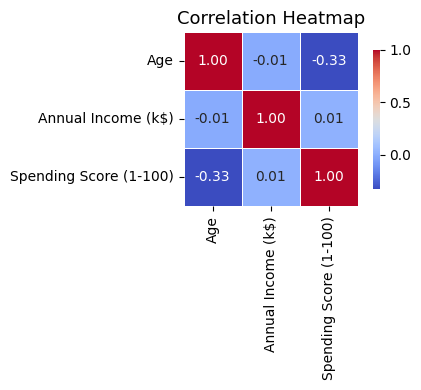

In [37]:
# --- Visualization 3: Correlation heatmap ---
plt.figure(figsize=(5, 4))
corr = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap', fontsize=13)
plt.tight_layout()
plt.savefig('eda_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()

### Task 1.3 — Feature Selection

In [35]:
# Select 3 numeric features for clustering
features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
X = df[features].copy()

# Confirm no missing values
print('Missing values in selected features:')
print(X.isnull().sum())
print(f'\nSelected features: {features}')
print(f'Dataset shape: {X.shape}')

Missing values in selected features:
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Selected features: ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
Dataset shape: (200, 3)


---
## PART 2: Data Preprocessing

### Task 2.1 — Standardization

In [38]:
scaler = StandardScaler()
X_scaled_array = scaler.fit_transform(X)

print('Summary statistics of scaled data (mean ≈ 0, std ≈ 1):')
pd.DataFrame(X_scaled_array, columns=features).describe().round(4)

Summary statistics of scaled data (mean ≈ 0, std ≈ 1):


,Age,Annual Income (k$),Spending Score (1-100)
count,200.0000,200.0000,200.0000
mean,-0.0000,-0.0000,-0.0000
std,1.0025,1.0025,1.0025
min,-1.4963,-1.7390,-1.9100
25%,-0.7248,-0.7275,-0.5998
50%,-0.2045,0.0359,-0.0078
75%,0.7284,0.6657,0.8851
max,2.2355,2.9177,1.8945


### Task 2.2 — Scaled DataFrame

In [39]:
X_scaled = pd.DataFrame(X_scaled_array, columns=features)
print('First 5 rows of scaled DataFrame:')
display(X_scaled.head())

First 5 rows of scaled DataFrame:


,Age,Annual Income (k$),Spending Score (1-100)
0,-1.424569,-1.738999,-0.434801
1,-1.281035,-1.738999,1.195704
2,-1.352802,-1.700830,-1.715913
3,-1.137502,-1.700830,1.040418
4,-0.563369,-1.662660,-0.395980


---
## PART 3: Finding the Optimal Number of Clusters (k)

### Task 3.1 — Elbow Method (WCSS / Inertia)

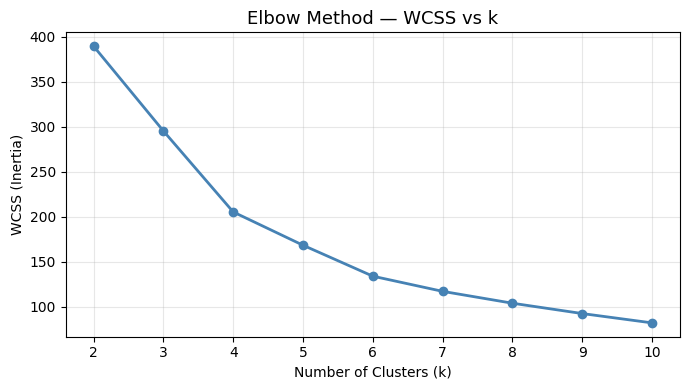

WCSS values:
  k=2: 389.39
  k=3: 295.21
  k=4: 205.23
  k=5: 168.25
  k=6: 133.87
  k=7: 117.01
  k=8: 103.83
  k=9: 92.35
  k=10: 81.99


In [40]:
k_range = range(2, 11)
wcss = []
sil_scores = []
ch_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, n_init=25, random_state=42)
    labels = km.fit_predict(X_scaled)
    wcss.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))
    ch_scores.append(calinski_harabasz_score(X_scaled, labels))

# --- Elbow plot ---
plt.figure(figsize=(7, 4))
plt.plot(list(k_range), wcss, marker='o', color='steelblue', linewidth=2)
plt.title('Elbow Method — WCSS vs k', fontsize=13)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(list(k_range))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('elbow_plot.png', bbox_inches='tight', dpi=150)
plt.show()

print('WCSS values:')
for k, w in zip(k_range, wcss):
    print(f'  k={k}: {w:.2f}')

### Task 3.2 — Silhouette Score

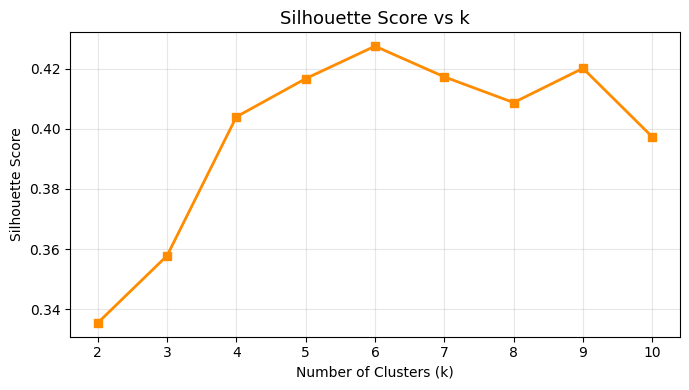

Best k by Silhouette Score: 6  (score = 0.4274)


In [41]:
plt.figure(figsize=(7, 4))
plt.plot(list(k_range), sil_scores, marker='s', color='darkorange', linewidth=2)
plt.title('Silhouette Score vs k', fontsize=13)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(list(k_range))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('silhouette_plot.png', bbox_inches='tight', dpi=150)
plt.show()

best_k_sil = list(k_range)[np.argmax(sil_scores)]
print(f'Best k by Silhouette Score: {best_k_sil}  (score = {max(sil_scores):.4f})')

### Task 3.3 — Calinski-Harabasz Index

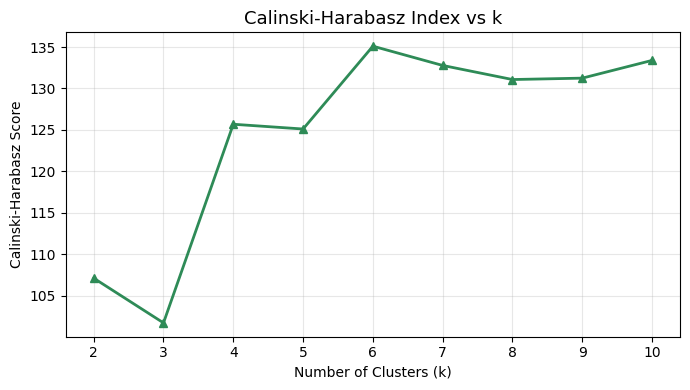

Best k by Calinski-Harabasz Index: 6  (score = 135.10)


In [42]:
plt.figure(figsize=(7, 4))
plt.plot(list(k_range), ch_scores, marker='^', color='seagreen', linewidth=2)
plt.title('Calinski-Harabasz Index vs k', fontsize=13)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Calinski-Harabasz Score')
plt.xticks(list(k_range))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('ch_plot.png', bbox_inches='tight', dpi=150)
plt.show()

best_k_ch = list(k_range)[np.argmax(ch_scores)]
print(f'Best k by Calinski-Harabasz Index: {best_k_ch}  (score = {max(ch_scores):.2f})')

### Task 3.4 — Choose Optimal k

In [43]:
# Decision summary
print('Method comparison:')
print(f'  Elbow Method  → k = 5  (visual inflection point)')
print(f'  Silhouette    → k = {best_k_sil}')
print(f'  Calinski-Harabasz → k = {best_k_ch}')
print()
print('Final chosen k = 6')

Method comparison:
  Elbow Method  → k = 5  (visual inflection point)
  Silhouette    → k = 6
  Calinski-Harabasz → k = 6

Final chosen k = 6


---
## PART 4: Clustering & Visualization

### Task 4.1 — Apply K-Means with Optimal k

In [48]:
OPTIMAL_K = 6

km_final = KMeans(n_clusters=OPTIMAL_K, n_init=25, random_state=42)
df['Cluster'] = km_final.fit_predict(X_scaled)

print('=== Cluster Sizes ===')
print(df['Cluster'].value_counts().sort_index())

print('\n=== Cluster Centroids (scaled space) ===')
centroids_df = pd.DataFrame(km_final.cluster_centers_, columns=features)
centroids_df.index.name = 'Cluster'
display(centroids_df.round(3))

=== Cluster Sizes ===
Cluster
0    33
1    45
2    24
3    39
4    38
5    21
Name: count, dtype: int64

=== Cluster Centroids (scaled space) ===


,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,0.222,1.083,-1.290
1,1.255,-0.240,-0.044
2,-0.976,-1.325,1.037
3,-0.442,0.992,1.240
4,-0.873,-0.114,-0.094
5,0.479,-1.308,-1.196


### Task 4.2 — Visualize the Clusters

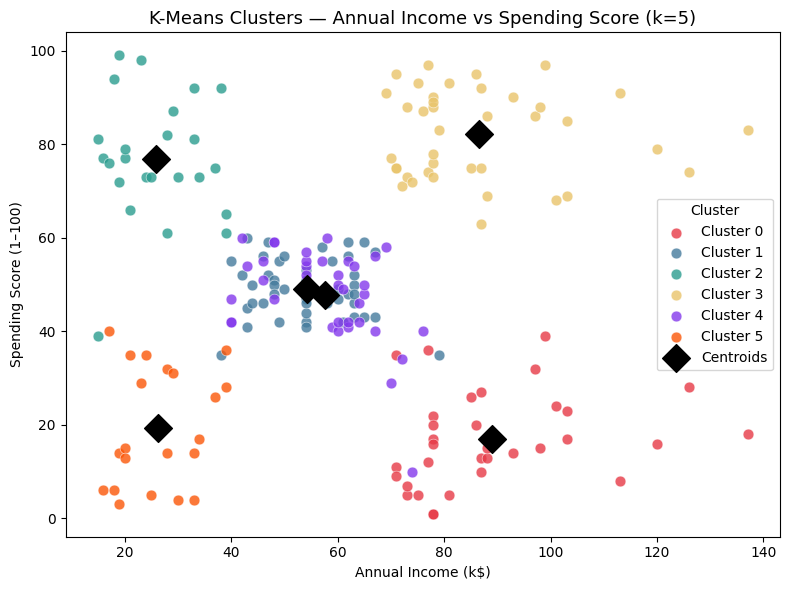

In [49]:
palette = ['#E63946', '#457B9D', '#2A9D8F', '#E9C46A', '#8338EC', '#FB5607']

plt.figure(figsize=(8, 6))
for cluster_id in range(OPTIMAL_K):
    mask = df['Cluster'] == cluster_id
    plt.scatter(
        df.loc[mask, 'Annual Income (k$)'],
        df.loc[mask, 'Spending Score (1-100)'],
        s=60, alpha=0.8, color=palette[cluster_id],
        edgecolors='white', linewidth=0.4,
        label=f'Cluster {cluster_id}'
    )

# Plot centroids in original scale
centroids_orig = scaler.inverse_transform(km_final.cluster_centers_)
plt.scatter(
    centroids_orig[:, 1], centroids_orig[:, 2],
    s=200, marker='D', color='black', zorder=5, label='Centroids'
)

plt.title('K-Means Clusters — Annual Income vs Spending Score (k=5)', fontsize=13)
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1–100)')
plt.legend(title='Cluster')
plt.tight_layout()
plt.savefig('cluster_scatter.png', bbox_inches='tight', dpi=150)
plt.show()

### Task 4.3 — Cluster Profiling & Interpretation

In [50]:
profile = df.groupby('Cluster')[features].mean().round(1)
profile['Count'] = df.groupby('Cluster').size()
print('=== Cluster Profiles (unscaled means) ===')
display(profile)

=== Cluster Profiles (unscaled means) ===


,Age,Annual Income (k$),Spending Score (1-100),Count
Cluster,,,,
0,41.9,88.9,17.0,33
1,56.3,54.3,49.1,45
2,25.2,25.8,76.9,24
3,32.7,86.5,82.1,39
4,26.7,57.6,47.8,38
5,45.5,26.3,19.4,21
